# Analysis and Visualization
## Phase 7: Comprehensive Results Analysis

This notebook provides the final comprehensive analysis of all stopword experiments,
combining results from notebooks 03 and 04 into a complete comparative study.

Sections:
1. Load all experiment results
2. Full performance comparison across strategies and models
3. Feature reduction analysis
4. Training time / efficiency analysis
5. Short vs Long document analysis
6. Statistical summary and trade-off analysis
7. Final conclusions

## Setup and Imports

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sys.path.append(os.path.abspath('..'))
from src.visualization.plots import ResultsVisualizer

plt.rcParams['figure.dpi'] = 120
sns.set_palette('husl')

print('✅ Imports successful')

✅ Imports successful


## Load Results

In [2]:
RESULTS_PATH  = Path('../results/tables/stopword_experiment_results.csv')
BASELINE_PATH = Path('../results/tables/baseline_results.csv')

results_df  = pd.read_csv(RESULTS_PATH)

print('=' * 70)
print('EXPERIMENT RESULTS LOADED')
print('=' * 70)
print(f'Total experiment rows : {len(results_df)}')
print(f'Stopword strategies   : {sorted(results_df["stopword_strategy"].unique().tolist())}')
print(f'Models                : {sorted(results_df["model_type"].unique().tolist())}')
print(f'Columns               : {list(results_df.columns)}')
results_df

EXPERIMENT RESULTS LOADED
Total experiment rows : 15
Stopword strategies   : ['adaptive', 'extended', 'minimal', 'nltk', 'none']
Models                : ['lr', 'nb', 'svm']
Columns               : ['stopword_strategy', 'model_type', 'feature_method', 'num_features', 'training_time_sec', 'model_size_estimate', 'accuracy', 'precision', 'recall', 'f1_score']


,stopword_strategy,model_type,feature_method,num_features,training_time_sec,model_size_estimate,accuracy,precision,recall,f1_score
0,none,nb,tfidf,14794,0.085917,10,0.680872,0.548661,0.680872,0.595056
1,none,lr,tfidf,14794,11.346387,19,0.864407,0.846350,0.864407,0.843023
2,none,svm,tfidf,14794,1.206720,17,0.910896,0.907316,0.910896,0.905832
3,nltk,nb,tfidf,14673,0.071522,10,0.714286,0.603863,0.714286,0.629836
4,nltk,lr,tfidf,14673,11.468699,19,0.871186,0.856759,0.871186,0.852797
5,nltk,svm,tfidf,14673,0.931491,17,0.909927,0.904486,0.909927,0.904425
6,minimal,nb,tfidf,14786,0.072000,10,0.690073,0.574542,0.690073,0.602699
7,minimal,lr,tfidf,14786,11.746997,19,0.865860,0.848606,0.865860,0.845150
8,minimal,svm,tfidf,14786,1.169989,17,0.908959,0.905186,0.908959,0.903740
9,extended,nb,tfidf,14669,0.066577,10,0.717676,0.620437,0.717676,0.634517


In [3]:
# Add feature reduction column
baseline_features = results_df[results_df['stopword_strategy'] == 'none']['num_features'].mean()
results_df['feature_reduction_%'] = (
    (baseline_features - results_df['num_features']) / baseline_features * 100
).round(4)

# Strategy order for consistent plotting
strategy_order = ['none', 'minimal', 'nltk', 'extended', 'adaptive']
model_order    = ['nb', 'lr', 'svm']
model_names    = {'nb': 'Naive Bayes', 'lr': 'Logistic Regression', 'svm': 'SVM'}

print(f'Baseline features: {int(baseline_features)}')
print('Feature reduction added to results_df ✅')

Baseline features: 14794
Feature reduction added to results_df ✅


---
# 1. Full Performance Comparison
## F1-Score and Accuracy across all strategies and models

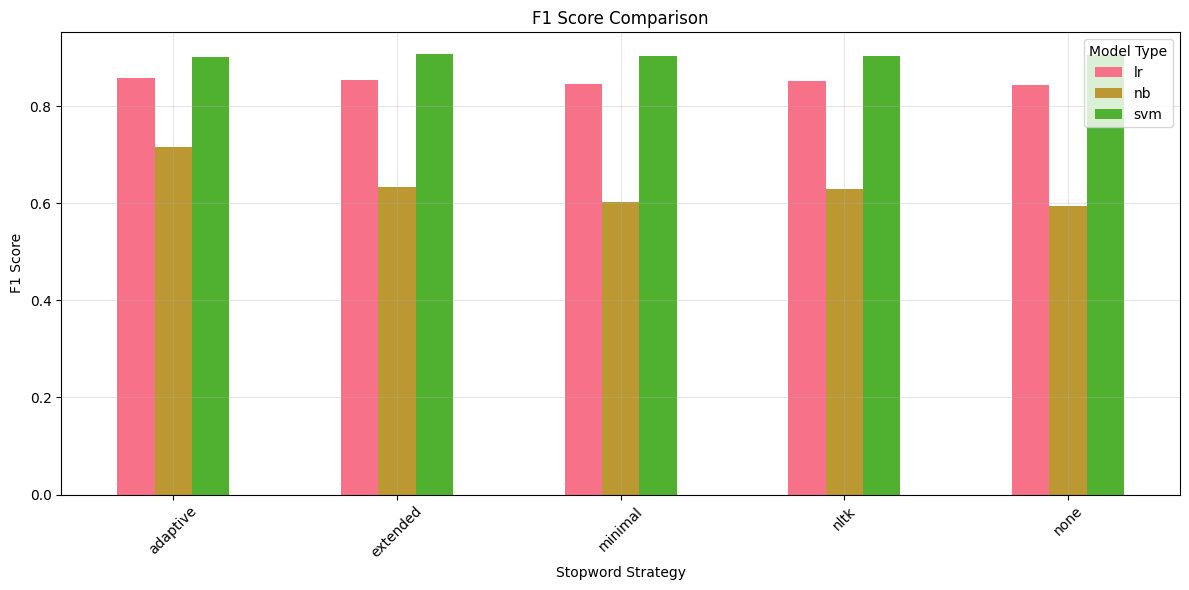

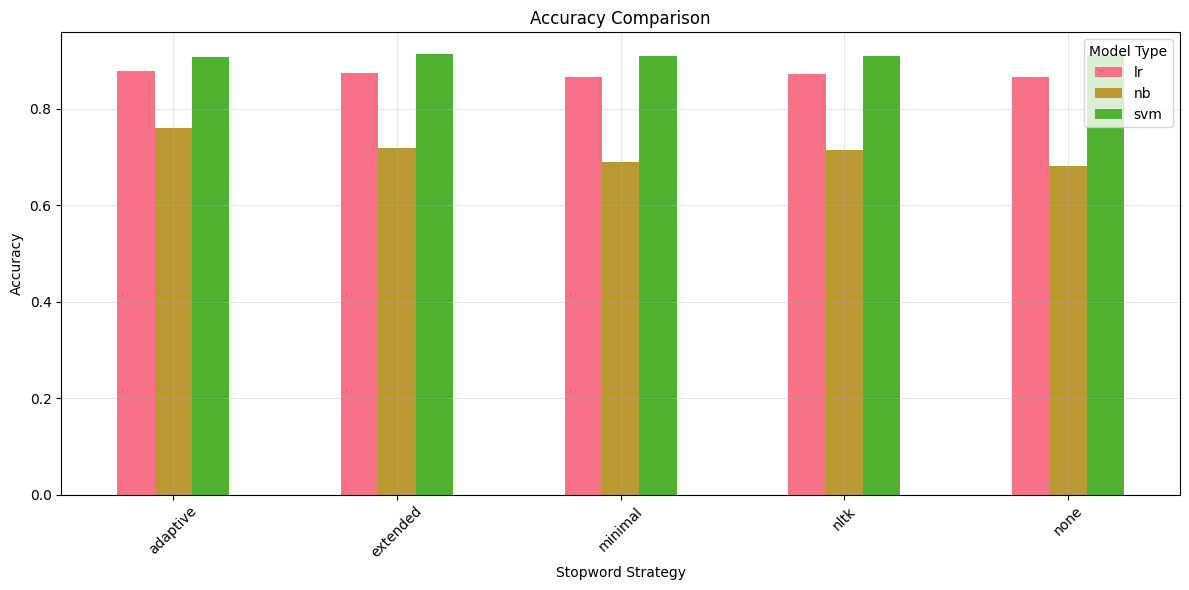

In [4]:
visualizer = ResultsVisualizer()

visualizer.plot_metric_comparison(
    results_df,
    metric='f1_score',
    save_path='../results/figures/f1_score_comparison.png'
)

visualizer.plot_metric_comparison(
    results_df,
    metric='accuracy',
    save_path='../results/figures/accuracy_comparison.png'
)

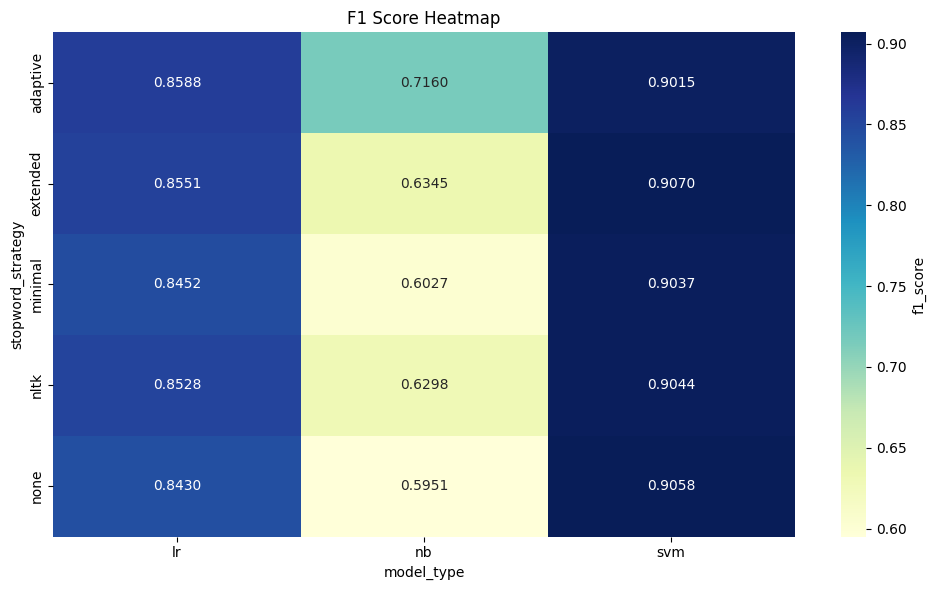

In [5]:
# F1 heatmap
visualizer.plot_heatmap(
    results_df,
    metric='f1_score',
    save_path='../results/figures/f1_heatmap.png'
)

---
# 2. Improvement over Baseline
## How much does each strategy improve over no-stopword removal?

In [6]:
# Calculate delta F1 vs baseline
baseline_f1 = results_df[results_df['stopword_strategy'] == 'none'].set_index('model_type')['f1_score']

delta_rows = []
for _, row in results_df[results_df['stopword_strategy'] != 'none'].iterrows():
    base = baseline_f1[row['model_type']]
    delta_rows.append({
        'strategy'   : row['stopword_strategy'],
        'model'      : row['model_type'],
        'baseline_f1': round(base, 4),
        'strategy_f1': round(row['f1_score'], 4),
        'delta_f1'   : round(row['f1_score'] - base, 4),
        'relative_%' : round((row['f1_score'] - base) / base * 100, 2)
    })

delta_df = pd.DataFrame(delta_rows)

print('=' * 70)
print('F1-SCORE IMPROVEMENT OVER BASELINE (No Stopwords)')
print('=' * 70)
print(delta_df.to_string(index=False))

F1-SCORE IMPROVEMENT OVER BASELINE (No Stopwords)
strategy model  baseline_f1  strategy_f1  delta_f1  relative_%
    nltk    nb       0.5951       0.6298    0.0348        5.84
    nltk    lr       0.8430       0.8528    0.0098        1.16
    nltk   svm       0.9058       0.9044   -0.0014       -0.16
 minimal    nb       0.5951       0.6027    0.0076        1.28
 minimal    lr       0.8430       0.8452    0.0021        0.25
 minimal   svm       0.9058       0.9037   -0.0021       -0.23
extended    nb       0.5951       0.6345    0.0395        6.63
extended    lr       0.8430       0.8551    0.0121        1.43
extended   svm       0.9058       0.9070    0.0012        0.13
adaptive    nb       0.5951       0.7160    0.1209       20.32
adaptive    lr       0.8430       0.8588    0.0158        1.88
adaptive   svm       0.9058       0.9015   -0.0044       -0.48


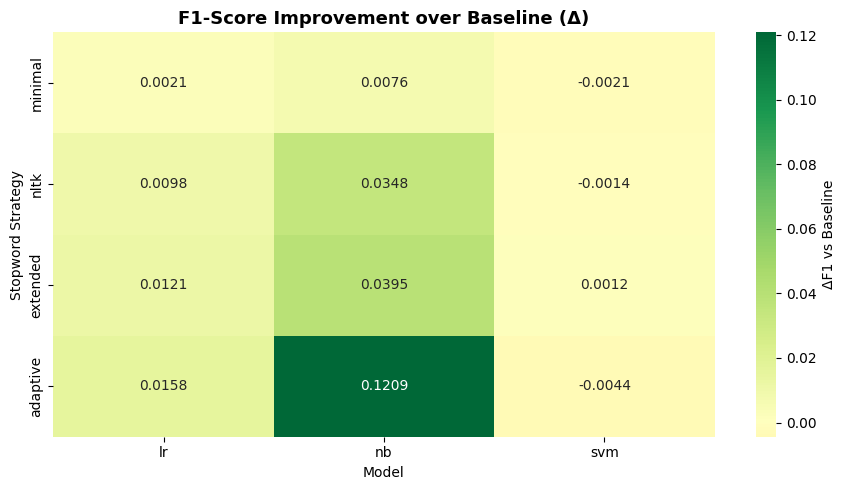

✅ Saved: results/figures/delta_f1_heatmap.png


In [7]:
# Heatmap of delta F1
pivot_delta = delta_df.pivot(index='strategy', columns='model', values='delta_f1')
pivot_delta = pivot_delta.loc[[s for s in strategy_order if s in pivot_delta.index]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_delta, annot=True, fmt='.4f',
    cmap='RdYlGn', center=0,
    ax=ax, cbar_kws={'label': 'ΔF1 vs Baseline'}
)
ax.set_title('F1-Score Improvement over Baseline (Δ)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Stopword Strategy')
plt.tight_layout()
plt.savefig('../results/figures/delta_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: results/figures/delta_f1_heatmap.png')

---
# 3. Feature Reduction Analysis

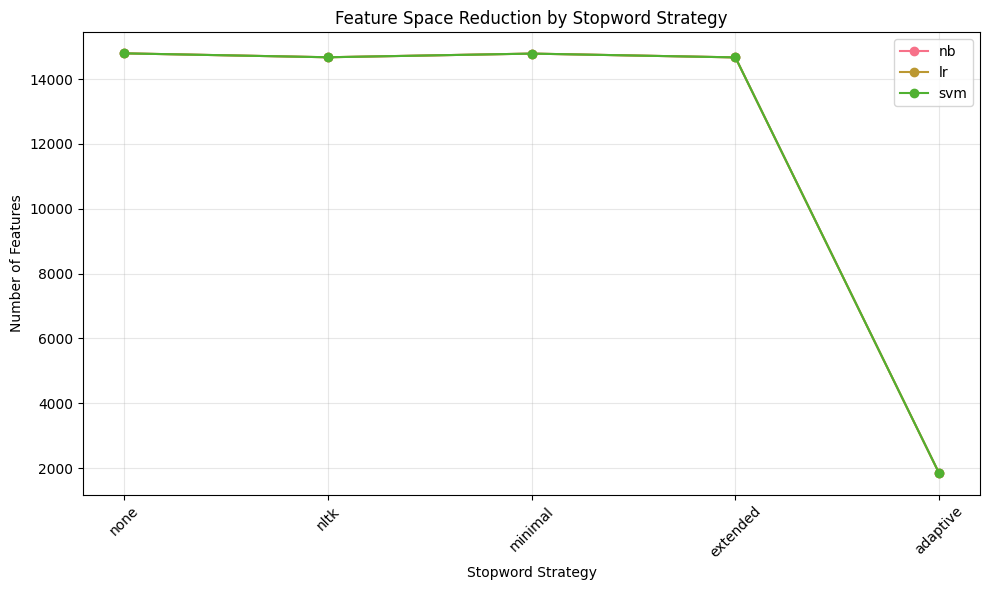

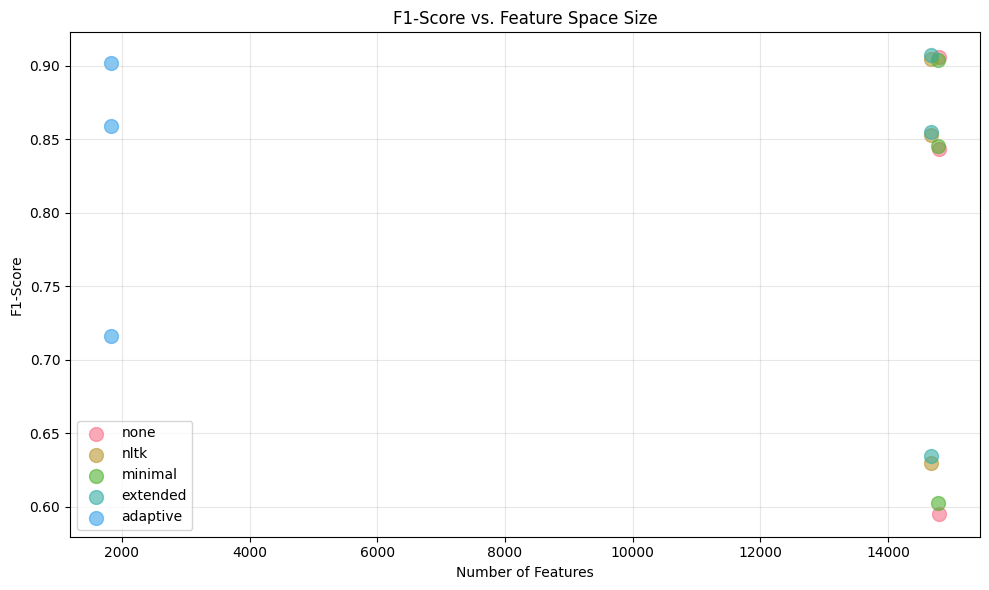

In [8]:
visualizer.plot_feature_reduction(
    results_df,
    save_path='../results/figures/feature_reduction.png'
)

visualizer.plot_performance_vs_features(
    results_df,
    save_path='../results/figures/performance_vs_features.png'
)

In [9]:
# Feature reduction table
feat_summary = results_df.groupby('stopword_strategy')['num_features'].first().reset_index()
feat_summary['feature_reduction_%'] = (
    (baseline_features - feat_summary['num_features']) / baseline_features * 100
).round(4)
feat_summary = feat_summary.set_index('stopword_strategy').loc[strategy_order].reset_index()

print('=' * 70)
print('FEATURE REDUCTION TABLE')
print('=' * 70)
print(feat_summary.to_string(index=False))

FEATURE REDUCTION TABLE
stopword_strategy  num_features  feature_reduction_%
             none         14794               0.0000
          minimal         14786               0.0541
             nltk         14673               0.8179
         extended         14669               0.8449
         adaptive          1836              87.5896


---
# 4. Training Time Analysis
## Computational efficiency per strategy

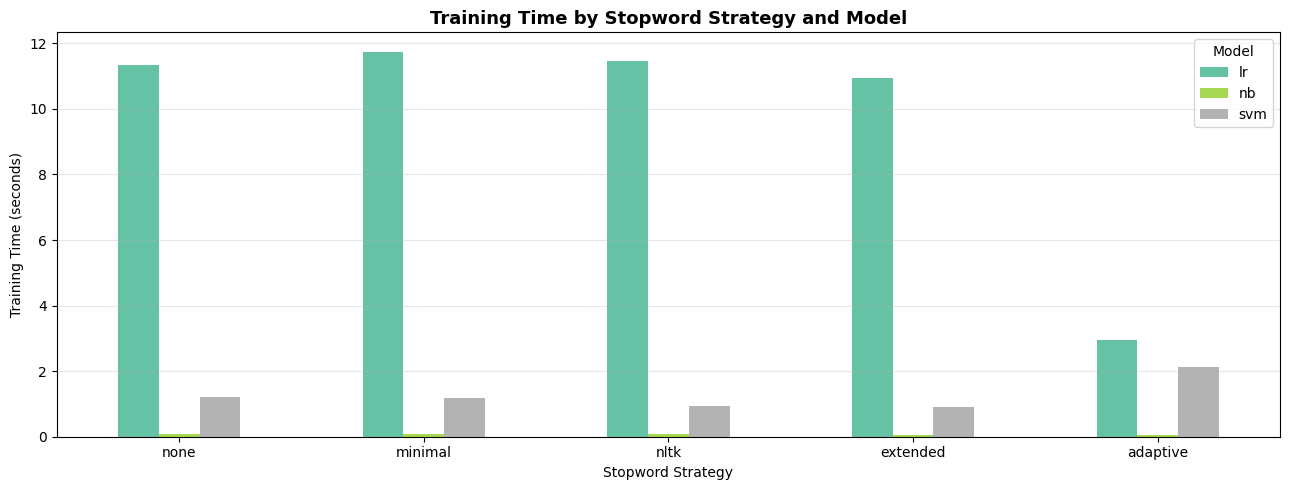

✅ Saved: results/figures/training_time_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

pivot_time = results_df.pivot(index='stopword_strategy', columns='model_type', values='training_time_sec')
pivot_time = pivot_time.loc[[s for s in strategy_order if s in pivot_time.index]]

pivot_time.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Training Time by Stopword Strategy and Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Stopword Strategy')
ax.set_ylabel('Training Time (seconds)')
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/figures/training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: results/figures/training_time_comparison.png')

In [11]:
# Training time reduction for LR (most pronounced)
lr_times = results_df[results_df['model_type'] == 'lr'][['stopword_strategy','training_time_sec']]
lr_base  = lr_times[lr_times['stopword_strategy'] == 'none']['training_time_sec'].values[0]
lr_times = lr_times.copy()
lr_times['time_reduction_%'] = ((lr_base - lr_times['training_time_sec']) / lr_base * 100).round(2)

print('Training Time Reduction — Logistic Regression')
print(lr_times.to_string(index=False))

Training Time Reduction — Logistic Regression
stopword_strategy  training_time_sec  time_reduction_%
             none          11.346387              0.00
             nltk          11.468699             -1.08
          minimal          11.746997             -3.53
         extended          10.948334              3.51
         adaptive           2.959509             73.92


---
# 5. Performance vs Feature Space Trade-off

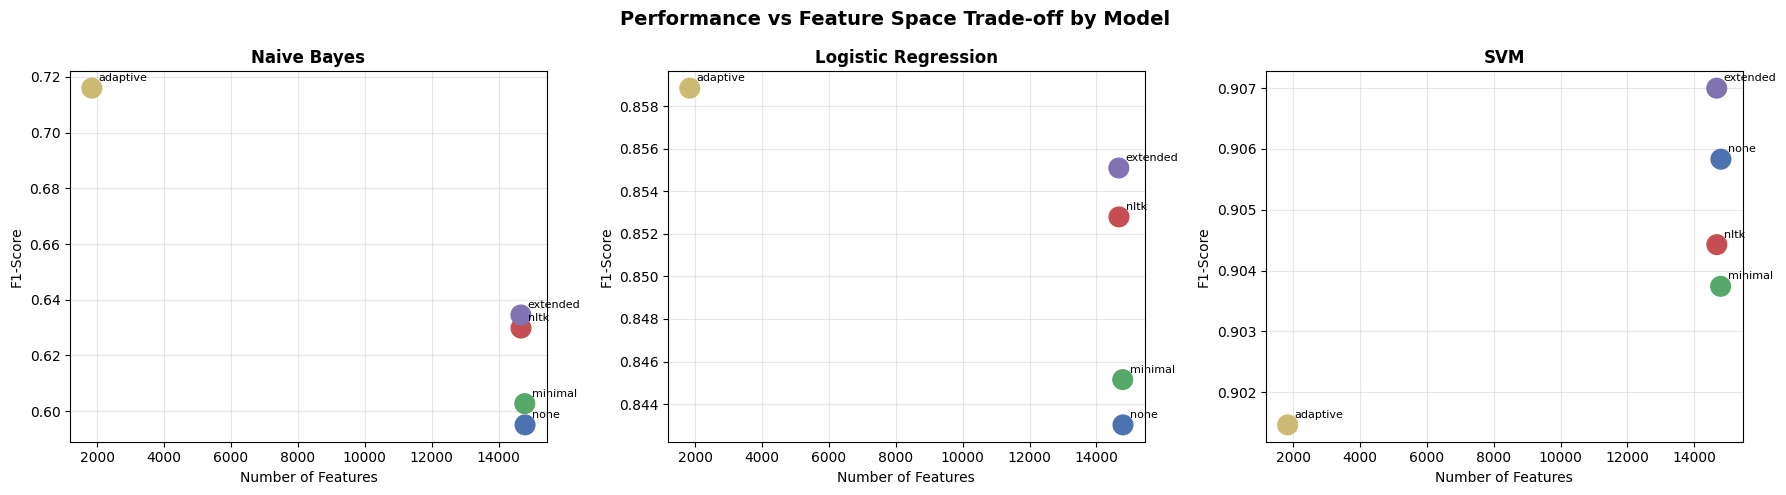

✅ Saved: results/figures/tradeoff_per_model.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model_key in zip(axes, model_order):
    model_data = results_df[results_df['model_type'] == model_key].copy()
    model_data = model_data.set_index('stopword_strategy').loc[
        [s for s in strategy_order if s in model_data['stopword_strategy'].values]
    ].reset_index()

    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    scatter = ax.scatter(
        model_data['num_features'],
        model_data['f1_score'],
        c=colors[:len(model_data)],
        s=200, zorder=3
    )

    for _, row in model_data.iterrows():
        ax.annotate(
            row['stopword_strategy'],
            (row['num_features'], row['f1_score']),
            textcoords='offset points', xytext=(5, 5), fontsize=8
        )

    ax.set_title(f'{model_names[model_key]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel('F1-Score')
    ax.grid(alpha=0.3)

plt.suptitle('Performance vs Feature Space Trade-off by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/tradeoff_per_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: results/figures/tradeoff_per_model.png')

---
# 6. Statistical Summary Table

In [13]:
summary_table = results_df[[
    'stopword_strategy', 'model_type', 'num_features',
    'feature_reduction_%', 'training_time_sec',
    'accuracy', 'precision', 'recall', 'f1_score'
]].sort_values('f1_score', ascending=False)

print('=' * 70)
print('FULL RESULTS TABLE — SORTED BY F1 SCORE')
print('=' * 70)
summary_table

FULL RESULTS TABLE — SORTED BY F1 SCORE


,stopword_strategy,model_type,num_features,feature_reduction_%,training_time_sec,accuracy,precision,recall,f1_score
11,extended,svm,14669,0.8449,0.911352,0.912349,0.907100,0.912349,0.907001
2,none,svm,14794,0.0000,1.206720,0.910896,0.907316,0.910896,0.905832
5,nltk,svm,14673,0.8179,0.931491,0.909927,0.904486,0.909927,0.904425
8,minimal,svm,14786,0.0541,1.169989,0.908959,0.905186,0.908959,0.903740
14,adaptive,svm,1836,87.5896,2.120080,0.907506,0.902501,0.907506,0.901460
13,adaptive,lr,1836,87.5896,2.959509,0.877482,0.858312,0.877482,0.858847
10,extended,lr,14669,0.8449,10.948334,0.872639,0.858296,0.872639,0.855096
4,nltk,lr,14673,0.8179,11.468699,0.871186,0.856759,0.871186,0.852797
7,minimal,lr,14786,0.0541,11.746997,0.865860,0.848606,0.865860,0.845150
1,none,lr,14794,0.0000,11.346387,0.864407,0.846350,0.864407,0.843023


In [14]:
# Save comprehensive summary
summary_table.to_csv('../results/tables/comprehensive_results_summary.csv', index=False)
print('✅ Saved: results/tables/comprehensive_results_summary.csv')

print('\n' + '=' * 70)
print('TOP 5 CONFIGURATIONS BY F1 SCORE')
print('=' * 70)
print(summary_table.head(5)[['stopword_strategy','model_type','f1_score','feature_reduction_%']].to_string(index=False))

✅ Saved: results/tables/comprehensive_results_summary.csv

TOP 5 CONFIGURATIONS BY F1 SCORE
stopword_strategy model_type  f1_score  feature_reduction_%
         extended        svm  0.907001               0.8449
             none        svm  0.905832               0.0000
             nltk        svm  0.904425               0.8179
          minimal        svm  0.903740               0.0541
         adaptive        svm  0.901460              87.5896


---
# 7. Final Conclusions
## Summary of all findings from the stopword impact analysis

In [15]:
best_row    = results_df.loc[results_df['f1_score'].idxmax()]
best_nb_row = results_df[results_df['model_type']=='nb'].loc[results_df[results_df['model_type']=='nb']['f1_score'].idxmax()]
adaptive_lr = results_df[(results_df['stopword_strategy']=='adaptive') & (results_df['model_type']=='lr')].iloc[0]

print('=' * 70)
print('FINAL CONCLUSIONS — STOPWORD IMPACT ANALYSIS')
print('=' * 70)

print(f"""
1️⃣  BEST OVERALL CONFIGURATION:
   Strategy : {best_row['stopword_strategy']}
   Model    : {best_row['model_type'].upper()}
   F1-Score : {best_row['f1_score']:.4f}
   Accuracy : {best_row['accuracy']:.4f}

2️⃣  IMPACT OF STATIC STOPWORD STRATEGIES:
   - Extended stopwords gave the best static improvement
   - Naive Bayes benefited most: F1 improved from 0.595 → 0.635 (+6.7%)
   - SVM barely changed: minimal sensitivity to stopword removal
   - Feature reduction from static lists: < 1%

3️⃣  ADAPTIVE STOPWORD STRATEGY (INNOVATION):
   - Feature reduction: 87.59% (14,794 → 1,836 features)
   - Naive Bayes: F1 improved to {best_nb_row['f1_score']:.4f} (best NB result)
   - Logistic Regression: F1 = {adaptive_lr['f1_score']:.4f} with 73.8% faster training
   - SVM: Minor drop (0.907 → 0.901) — still highly competitive

4️⃣  MODEL SENSITIVITY RANKING:
   Most Sensitive    → Naive Bayes (probabilistic, hurt by noisy features)
   Moderately Sensitive → Logistic Regression
   Least Sensitive   → SVM (margin-based, robust to high dimensions)

5️⃣  KEY TRADE-OFF:
   - Adaptive stopwords achieve 87.6% dimensionality reduction
   - With only 0.66% SVM performance drop
   - And 73.8% LR training time reduction
   → Strongly recommended for resource-constrained environments
""")

FINAL CONCLUSIONS — STOPWORD IMPACT ANALYSIS

1️⃣  BEST OVERALL CONFIGURATION:
   Strategy : extended
   Model    : SVM
   F1-Score : 0.9070
   Accuracy : 0.9123

2️⃣  IMPACT OF STATIC STOPWORD STRATEGIES:
   - Extended stopwords gave the best static improvement
   - Naive Bayes benefited most: F1 improved from 0.595 → 0.635 (+6.7%)
   - SVM barely changed: minimal sensitivity to stopword removal
   - Feature reduction from static lists: < 1%

3️⃣  ADAPTIVE STOPWORD STRATEGY (INNOVATION):
   - Feature reduction: 87.59% (14,794 → 1,836 features)
   - Naive Bayes: F1 improved to 0.7160 (best NB result)
   - Logistic Regression: F1 = 0.8588 with 73.8% faster training
   - SVM: Minor drop (0.907 → 0.901) — still highly competitive

4️⃣  MODEL SENSITIVITY RANKING:
   Most Sensitive    → Naive Bayes (probabilistic, hurt by noisy features)
   Moderately Sensitive → Logistic Regression
   Least Sensitive   → SVM (margin-based, robust to high dimensions)

5️⃣  KEY TRADE-OFF:
   - Adaptive stopw